<a href="https://www.kaggle.com/code/prakashhh2409/automatic-helmet-detection-n-no-plate-2?scriptVersionId=355441209" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install -q ultralytics

import os, glob, random, yaml
from pathlib import Path
import torch, cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings

settings.update({"wandb": False})          # avoid W&B login prompts on Kaggle
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 3.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
CUDA available: True
GPU: Tesla T4


In [2]:
candidates = glob.glob("/kaggle/input/**/data.yaml", recursive=True)
if not candidates:
    candidates = glob.glob("/kaggle/input/**/*.yaml", recursive=True)
assert candidates, "No yaml found - check that the dataset is attached under 'Input'."

yaml_path = Path(candidates[0])
print("Using:", yaml_path, "\n(all found:", candidates, ")\n")

with open(yaml_path) as f:
    cfg = yaml.safe_load(f)
print(yaml.dump(cfg, sort_keys=False))

Using: /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/dataset.yaml 
(all found: ['/kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/dataset.yaml', '/kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/plate_train_val/dataset.yaml', '/kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/helmet_no_helmet_train_val/dataset.yaml', '/kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/twowheeler_train_val/dataset.yaml'] )

path: /content/drive/MyDrive/MP/final_dataset/rider_train_val
train: train/images
val: val/images
nc: 1
names:
- rider



In [3]:
# --- 1. Classes ---
names = cfg["names"]
names = [names[k] for k in sorted(names)] if isinstance(names, dict) else list(names)
print(f"nc in yaml: {cfg.get('nc')} | actual names: {len(names)} -> {names}")

expected = {"WithHelmet", "WithoutHelmet", "TripleRiding", "Plate"}
print("Matches your expected classes:", set(names) == expected)
if set(names) != expected:
    print("  Missing from dataset:", expected - set(names))
    print("  Extra in dataset:    ", set(names) - expected)
assert cfg.get("nc", len(names)) == len(names), "nc and names length disagree - fix before training!"

# --- 2. Path resolution ---
root = Path(cfg.get("path", yaml_path.parent))
if not root.is_absolute():
    root = (yaml_path.parent / root).resolve()

def resolve(p):
    if p is None:
        return None
    p = Path(p)
    if p.is_absolute():
        return p
    stripped = Path(*[x for x in p.parts if x != ".."])   # handles '../train/images'
    for c in [root / p, yaml_path.parent / p, root / stripped, yaml_path.parent / stripped]:
        if c.resolve().exists():
            return c.resolve()
    return (root / p).resolve()

splits = {s: resolve(cfg.get(s)) for s in ["train", "val", "test"]}

# --- 3. Sanity check ---
img_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
for s, p in splits.items():
    if p is None:
        print(f"{s:5s}: not defined in yaml")
        continue
    ok = p.exists()
    n = sum(1 for f in p.iterdir() if f.suffix.lower() in img_ext) if ok else 0
    lbl = Path(str(p).replace("/images", "/labels"))
    print(f"{s:5s}: exists={ok} | images={n} | labels dir exists={lbl.exists()} | {p}")
assert splits["train"] and splits["train"].exists(), "Train path is broken"
assert splits["val"] and splits["val"].exists(), "Val path is broken"

# --- 4. Write fixed yaml (writable location) ---
fixed = {
    "path": "",
    "train": str(splits["train"]),
    "val": str(splits["val"]),
    "nc": len(names),
    "names": names,
}
if splits["test"] and splits["test"].exists():
    fixed["test"] = str(splits["test"])

DATA_YAML = "/kaggle/working/data_fixed.yaml"
with open(DATA_YAML, "w") as f:
    yaml.dump(fixed, f, sort_keys=False)
print("\nWrote", DATA_YAML)

nc in yaml: 1 | actual names: 1 -> ['rider']
Matches your expected classes: False
  Missing from dataset: {'WithoutHelmet', 'WithHelmet', 'Plate', 'TripleRiding'}
  Extra in dataset:     {'rider'}
train: exists=True | images=234 | labels dir exists=True | /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/train/images
val  : exists=True | images=58 | labels dir exists=True | /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/val/images
test : not defined in yaml

Wrote /kaggle/working/data_fixed.yaml


In [4]:
def on_train_epoch_end(trainer):
    items = trainer.label_loss_items(trainer.tloss, prefix="train")
    msg = " | ".join(f"{k}: {v:.4f}" for k, v in items.items())
    print(f"[Epoch {trainer.epoch + 1}/{trainer.epochs}] {msg}")

def on_fit_epoch_end(trainer):
    val = {k: v for k, v in trainer.metrics.items() if "loss" in k}
    msg = " | ".join(f"{k}: {v:.4f}" for k, v in val.items())
    print(f"               VAL -> {msg} | mAP50: {trainer.metrics.get('metrics/mAP50(B)', 0):.4f}")

def attach(model):
    model.add_callback("on_train_epoch_end", on_train_epoch_end)
    model.add_callback("on_fit_epoch_end", on_fit_epoch_end)
    return model

In [5]:
MODEL_WEIGHTS = "yolov8s.pt"     # use "yolov8n.pt" for faster, slightly less accurate runs

model = attach(YOLO(MODEL_WEIGHTS))
model.train(
    data=DATA_YAML,
    epochs=5,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,                    # single GPU avoids DDP issues on Kaggle
    project="/kaggle/working/runs",
    name="diagnostic",
    exist_ok=True,
    plots=True,
    # ---------- CONTINGENCIES: if loss is high / not decreasing, try ONE at a time ----------
    # 1. Re-check data_fixed.yaml: nc must equal len(names), class names correct, and open a few
    #    label .txt files (class_id x y w h, all normalized 0-1, class_id < nc).
    # 2. Lower the LR:        lr0=0.001, lrf=0.01   (or 0.0001 if still unstable)
    # 3. Change optimizer:    optimizer="AdamW"     (default 'auto' may pick SGD)
    # 4. Freeze backbone:     freeze=10             (stabilizes early epochs; unfreeze for the full run)
    # 5. Close mosaic late:   close_mosaic=10       (used in the full run below)
    # 6. Soften augmentation: mosaic=0.5, mixup=0.0
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=diagnostic, nbs=64, nms=None, opset=None, optimize=False, o

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


        2/5       4.3G      1.878      3.381      1.846         14        640: 100% ━━━━━━━━━━━━ 15/15 5.7it/s 2.6s
[Epoch 2/5] train/box_loss: 1.8779 | train/cls_loss: 3.3813 | train/dfl_loss: 1.8460
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.0it/s 0.5s
                   all         58         95     0.0052     0.0211    0.00152   0.000389
               VAL -> val/box_loss: 2.7148 | val/cls_loss: 4.7017 | val/dfl_loss: 3.4274 | mAP50: 0.0015

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        3/5       4.3G      1.758      2.654      1.759         16        640: 100% ━━━━━━━━━━━━ 15/15 4.6it/s 3.3s
[Epoch 3/5] train/box_loss: 1.7576 | train/cls_loss: 2.6540 | train/dfl_loss: 1.7591
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.8it/s 0.4s
                   all         58         95      0.207      0.126     0.05

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b417867bad0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
EPOCHS = 80

model = attach(YOLO(MODEL_WEIGHTS))
model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    patience=20,                 # early stop if val metrics don't improve for 20 epochs
    close_mosaic=10,             # turn off mosaic for the last 10 epochs (sharper final boxes)
    optimizer="auto",            # switch to "AdamW" + lr0=0.001 if the diagnostic run was unstable
    # freeze=10,                 # uncomment if early training was unstable
    # hsv_v=0.6,                 # optional: stronger brightness jitter helps with low-light images
    project="/kaggle/working/runs",
    name="full",
    exist_ok=True,
    plots=True,
)
BEST = str(model.trainer.best)
print("Best weights:", BEST)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=full, nbs=64, nms=None, opset=None, optimize=False, optimi

In [7]:
best_model = YOLO(BEST)
m = best_model.val(data=DATA_YAML, split="val", imgsz=640)

print("\n===== OVERALL (val) =====")
print(f"Precision : {m.box.mp:.4f}")
print(f"Recall    : {m.box.mr:.4f}")
print(f"mAP50     : {m.box.map50:.4f}")
print(f"mAP50-95  : {m.box.map:.4f}")

print("\n===== PER CLASS (mAP50-95) =====")
for i, c in enumerate(m.box.ap_class_index):
    print(f"{best_model.names[c]:15s} {m.box.maps[c]:.4f}")

# Same check on the held-out test set, if one exists
if "test" in fixed:
    mt = best_model.val(data=DATA_YAML, split="test", imgsz=640)
    print(f"\nTEST -> mAP50: {mt.box.map50:.4f} | mAP50-95: {mt.box.map:.4f}")

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 719.3±416.4 MB/s, size: 744.1 KB)
val: Scanning /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/val/labels... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 647.8it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6it/s 2.4s
                   all         58         95      0.804      0.642      0.746      0.479
Speed: 4.9ms preprocess, 14.3ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

===== OVERA

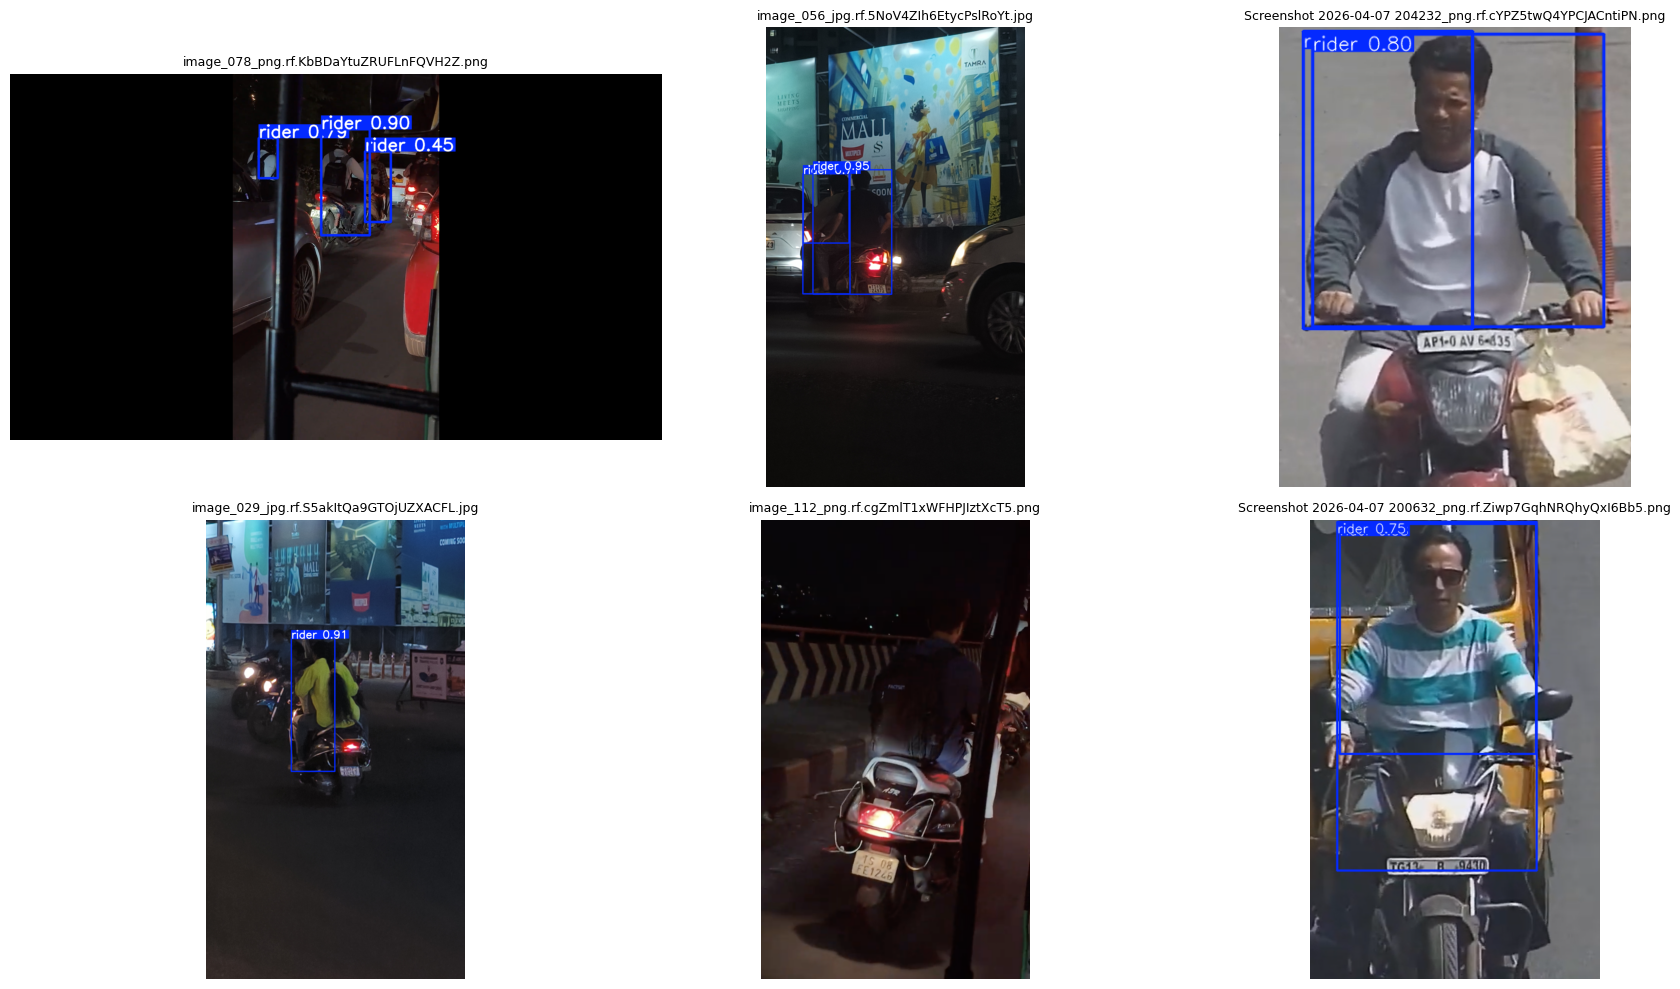

In [8]:
img_dir = Path(fixed.get("test", fixed["val"]))
imgs = [p for p in img_dir.iterdir() if p.suffix.lower() in img_ext]
samples = random.sample(imgs, min(6, len(imgs)))

results = best_model.predict(source=[str(p) for p in samples], conf=0.25, imgsz=640, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, r in zip(axes.ravel(), results):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(Path(r.path).name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

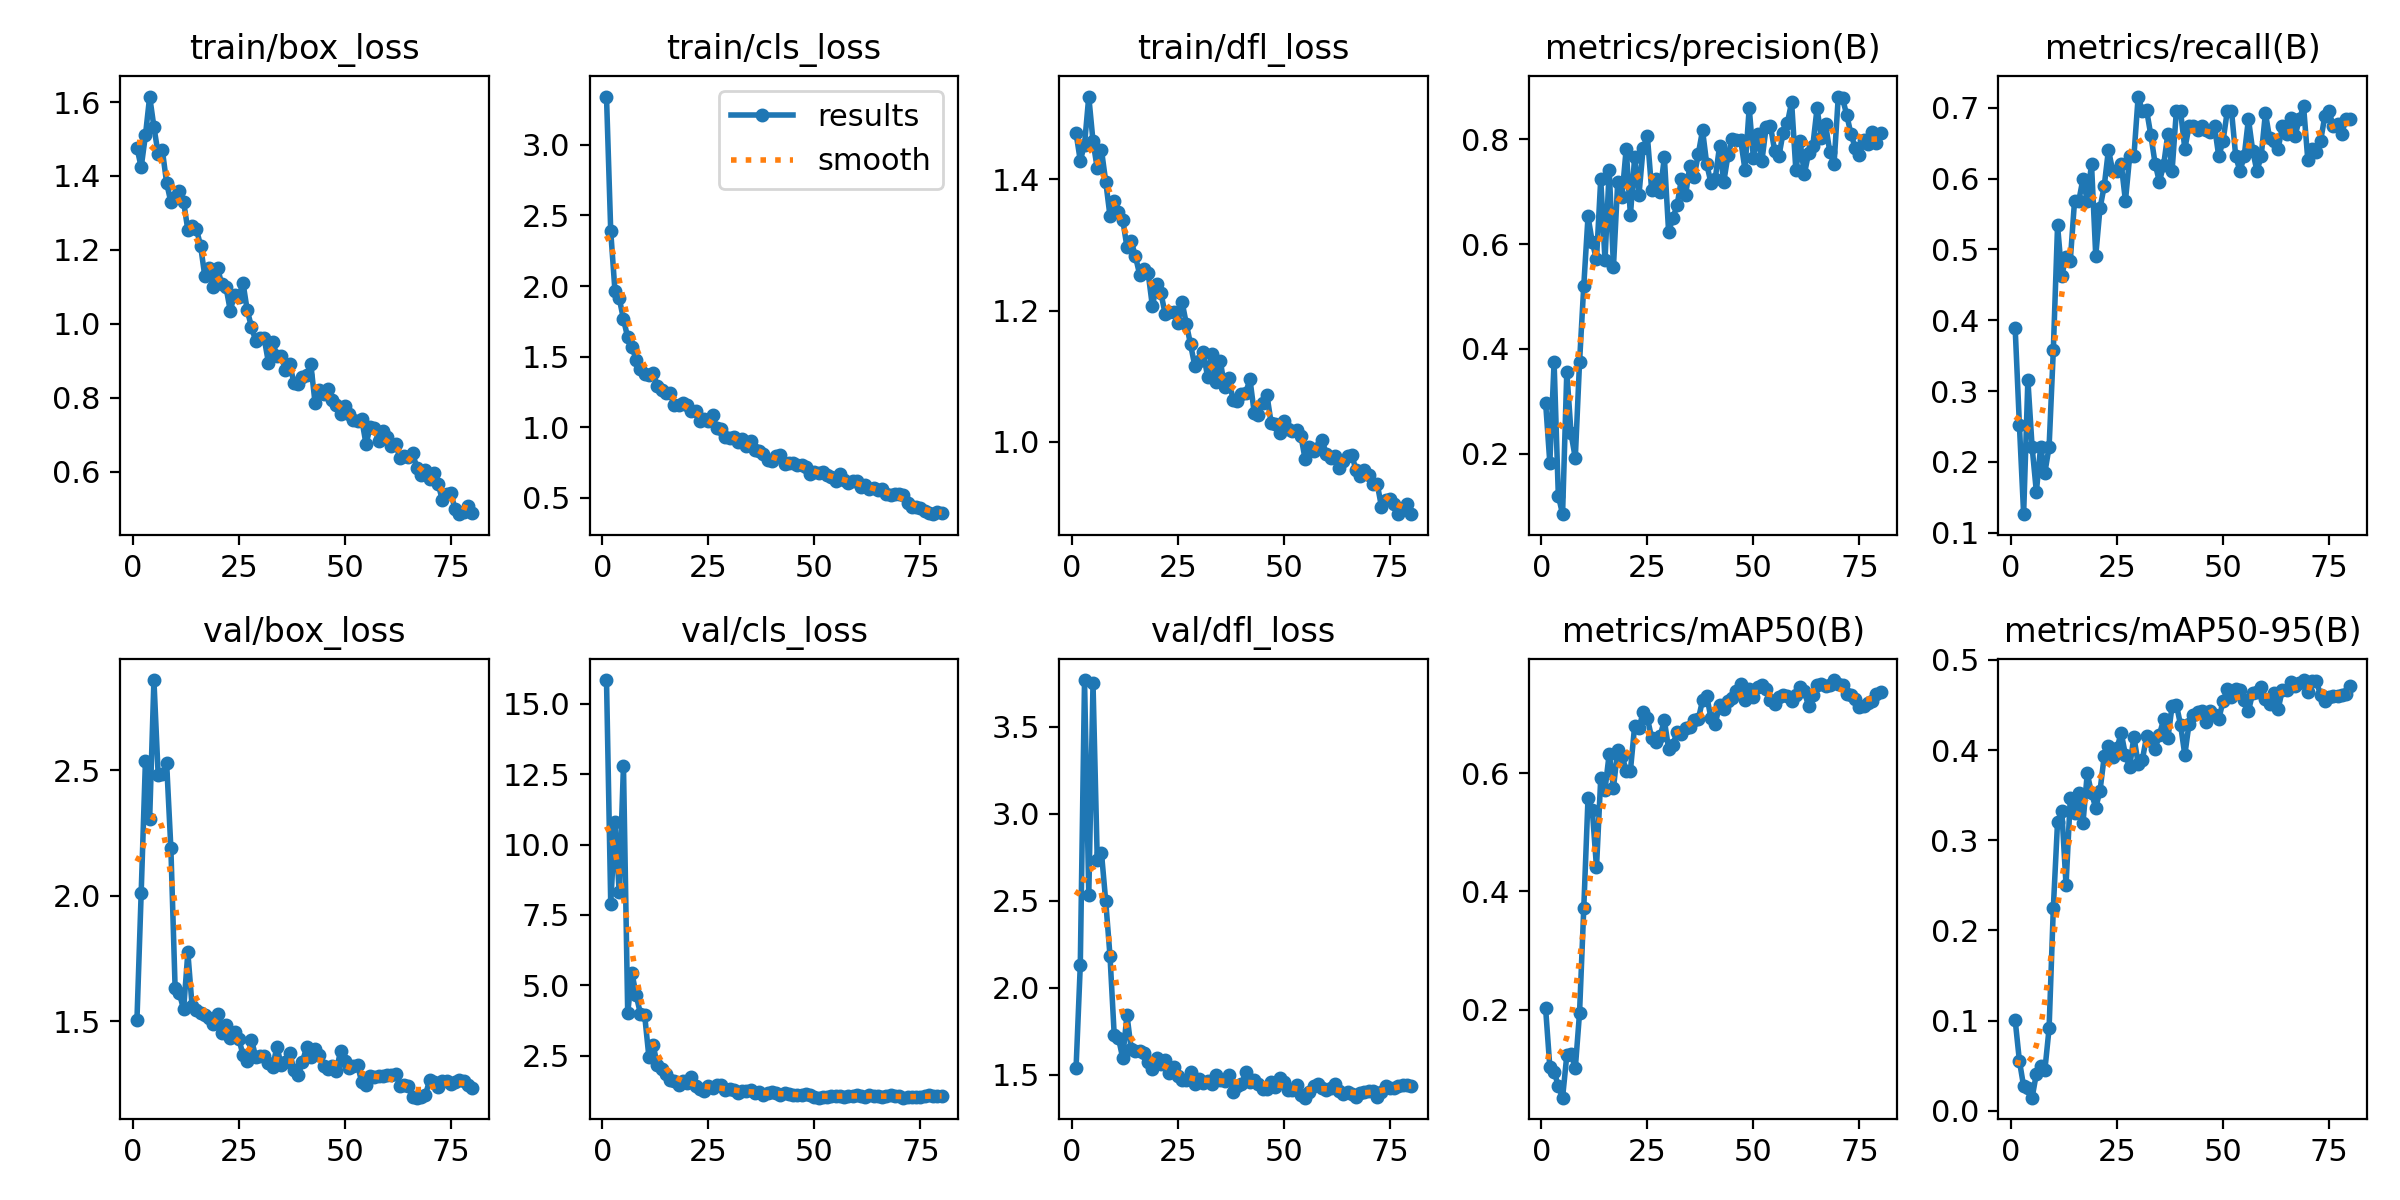

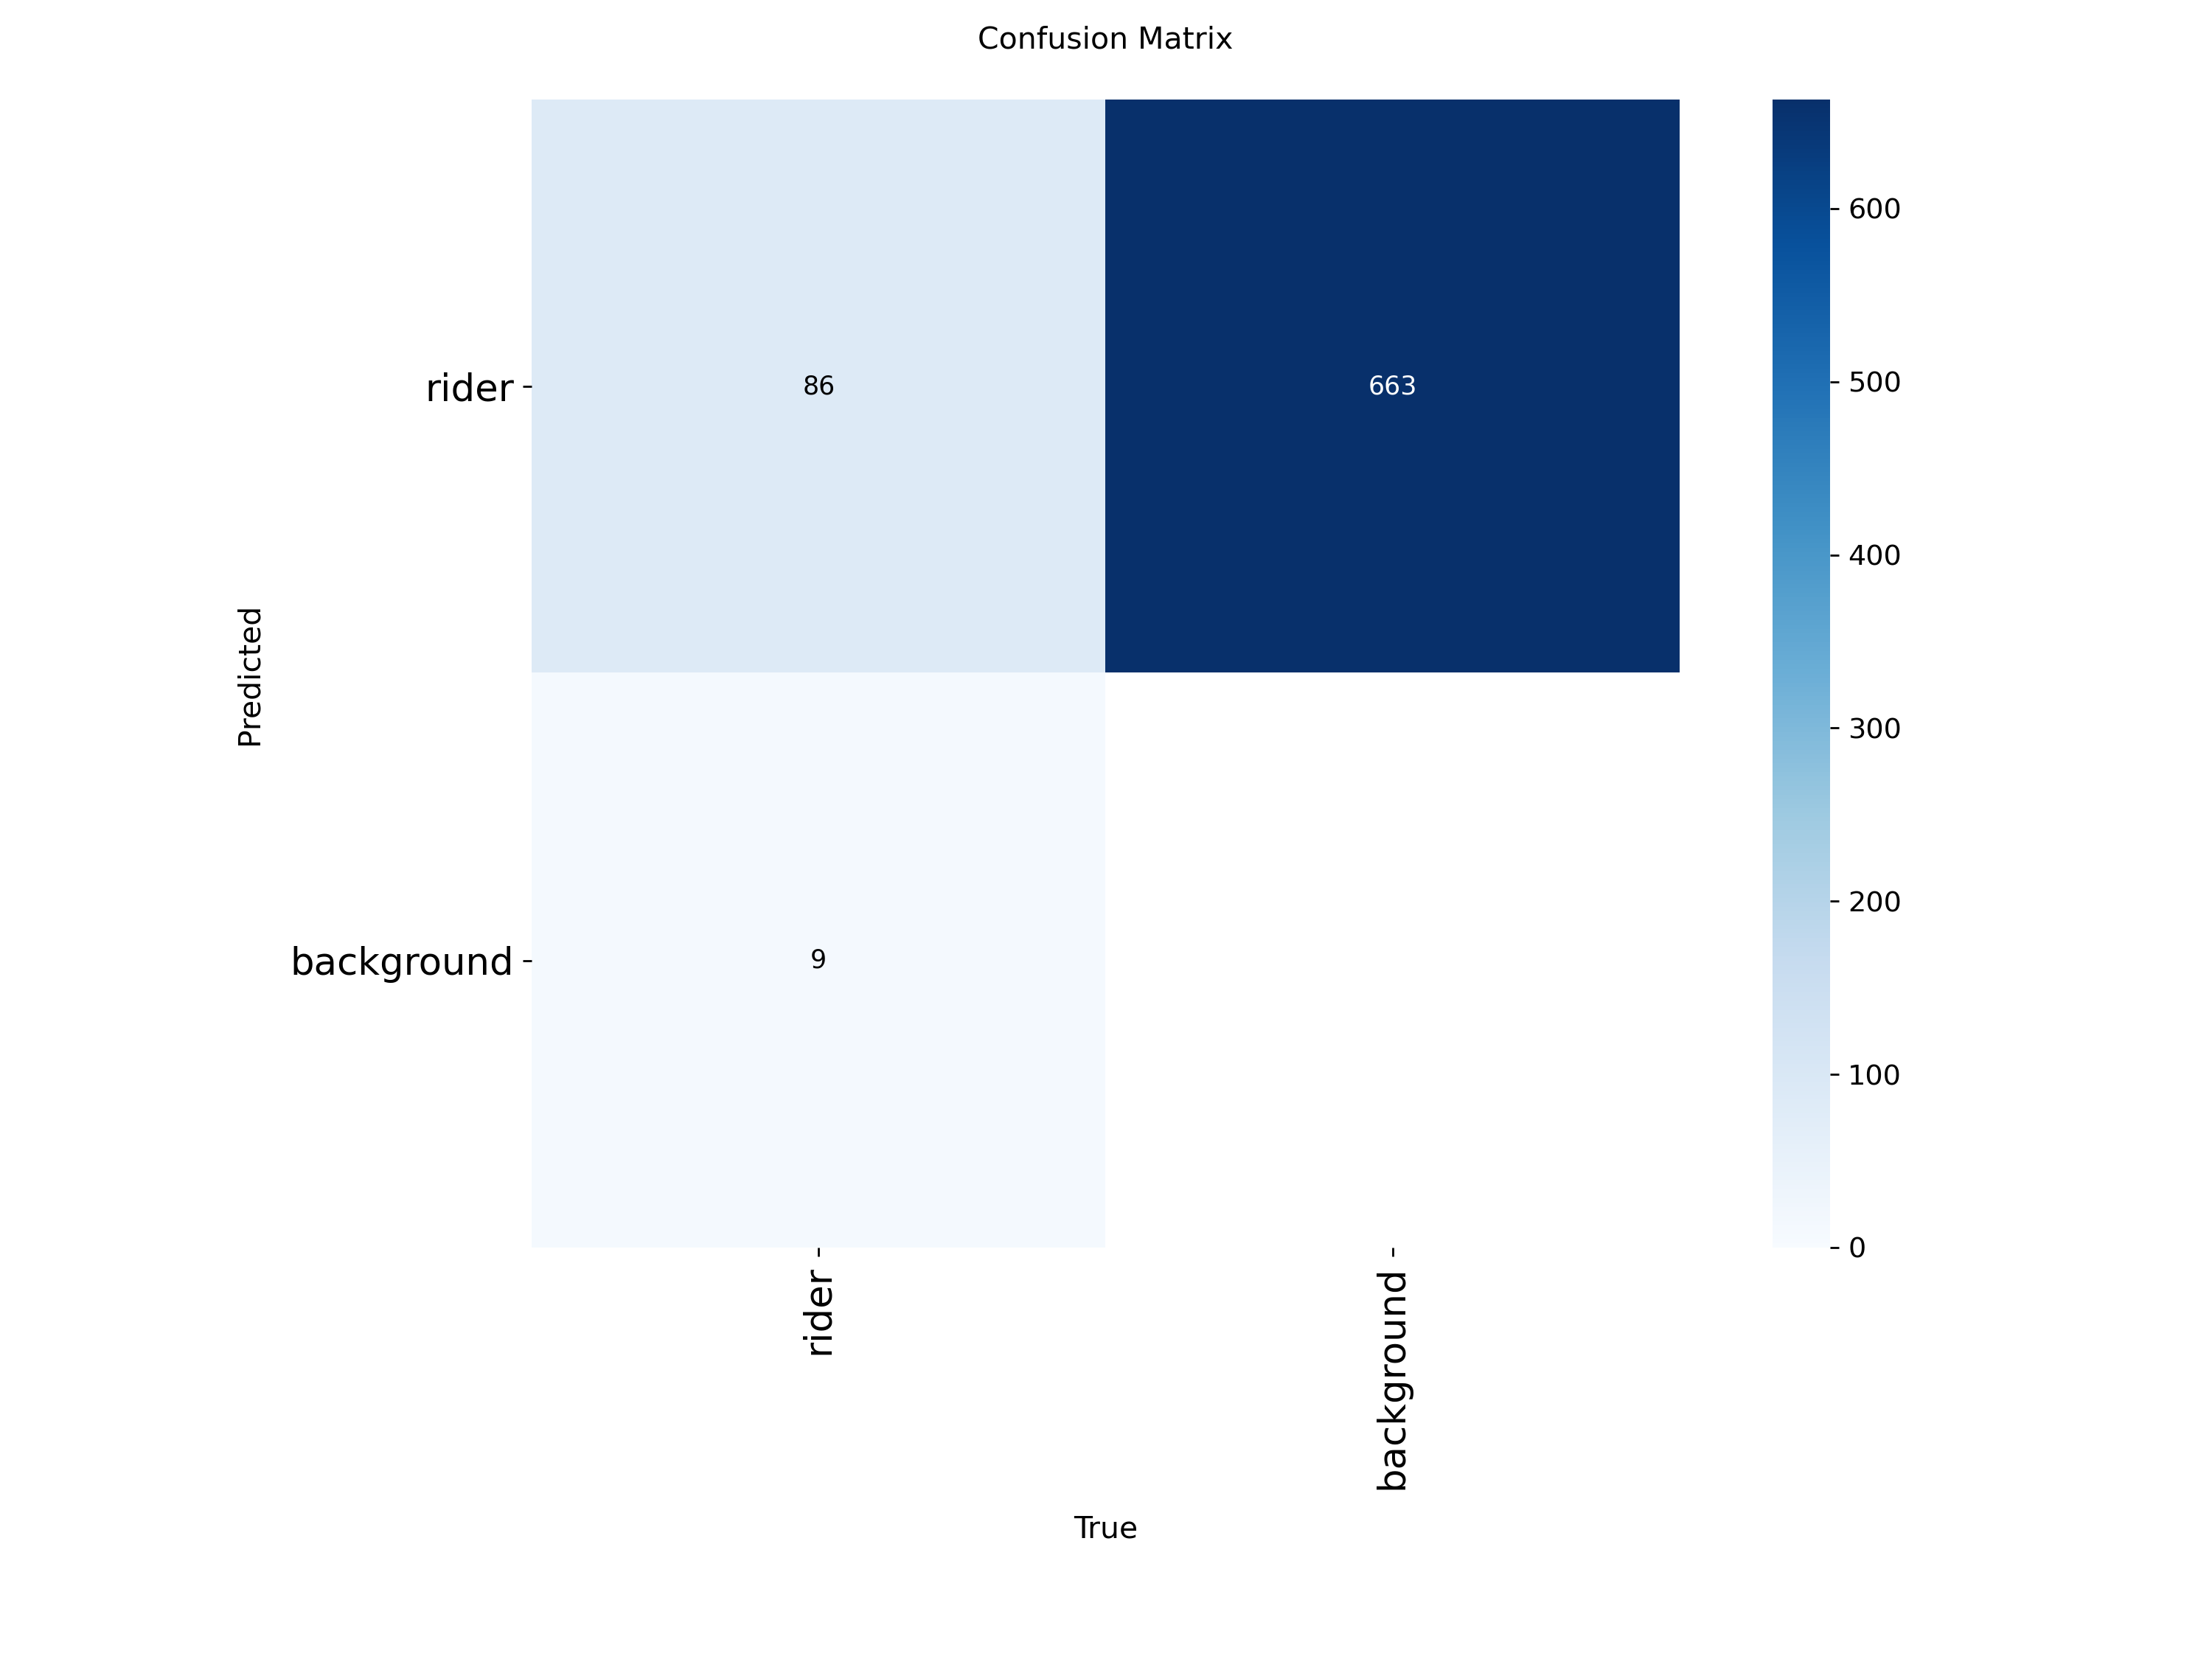

In [9]:
from IPython.display import Image, display
run_dir = Path(BEST).parent.parent
for f in ["results.png", "confusion_matrix.png"]:
    if (run_dir / f).exists():
        display(Image(str(run_dir / f)))


  Model   : diagnostic
  Weights : /kaggle/working/runs/diagnostic/weights/best.pt
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 402.1±251.0 MB/s, size: 502.2 KB)
val: Scanning /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/val/labels... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 477.5it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.6s
                   all         58         95      0.578      0.463      0.468      0.245
Speed: 3.9ms preprocess, 9.0ms inference, 0.0ms loss, 1.8ms 

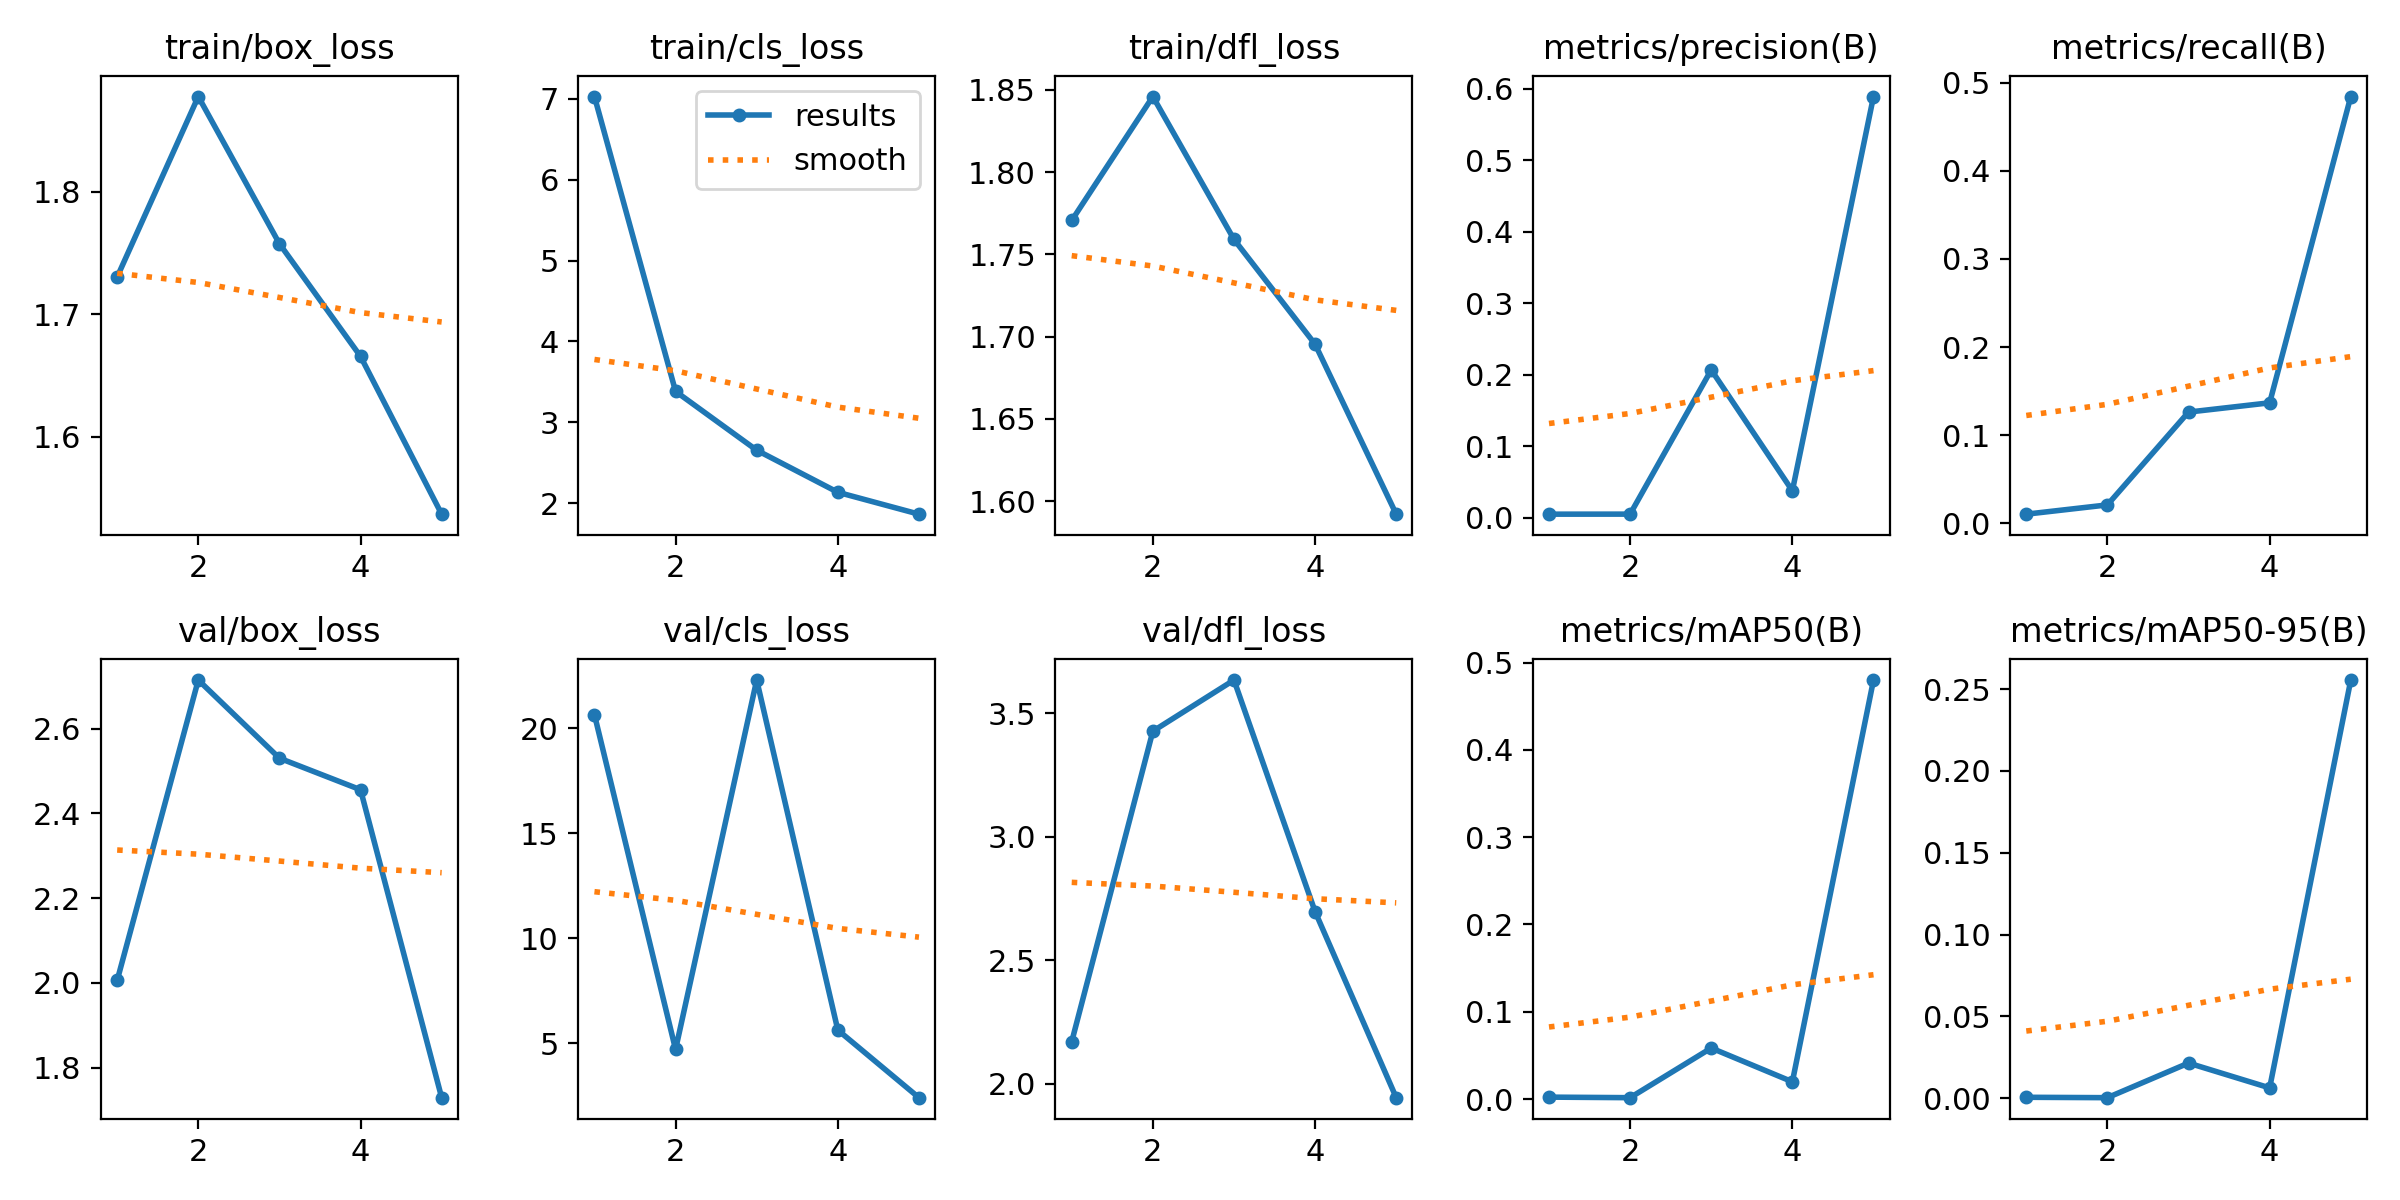


  confusion_matrix_normalized.png:


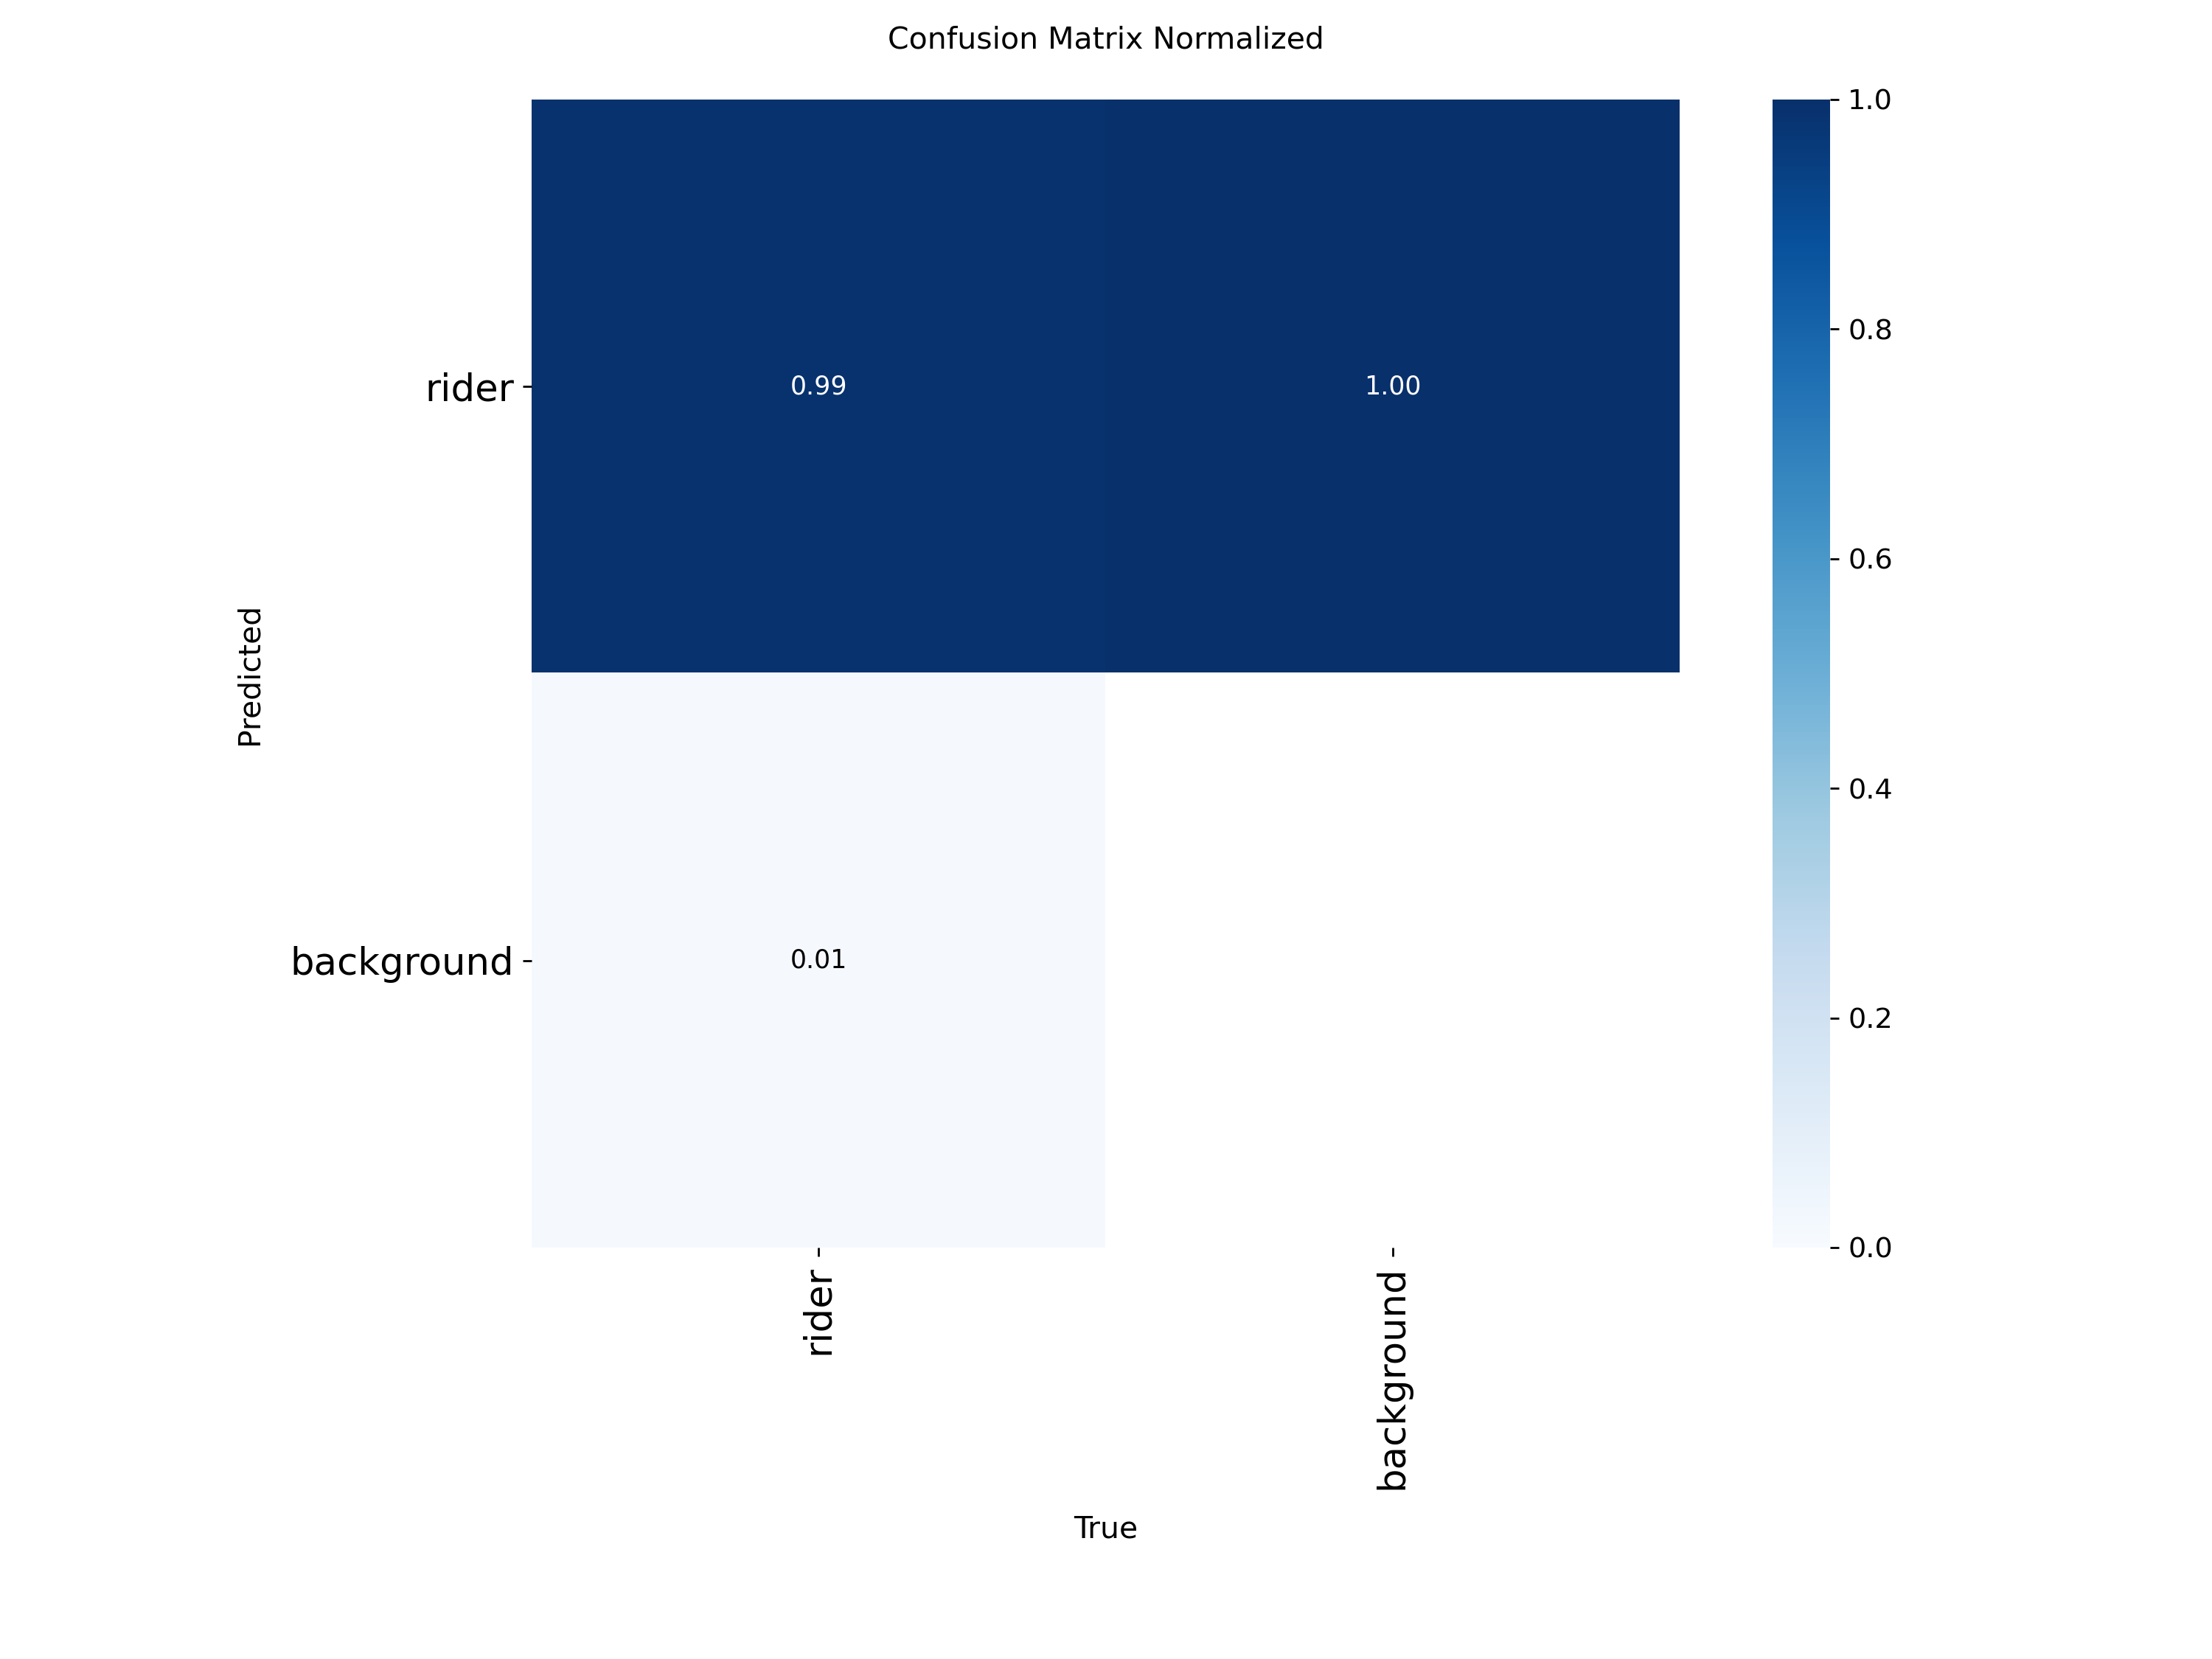


  confusion_matrix.png:


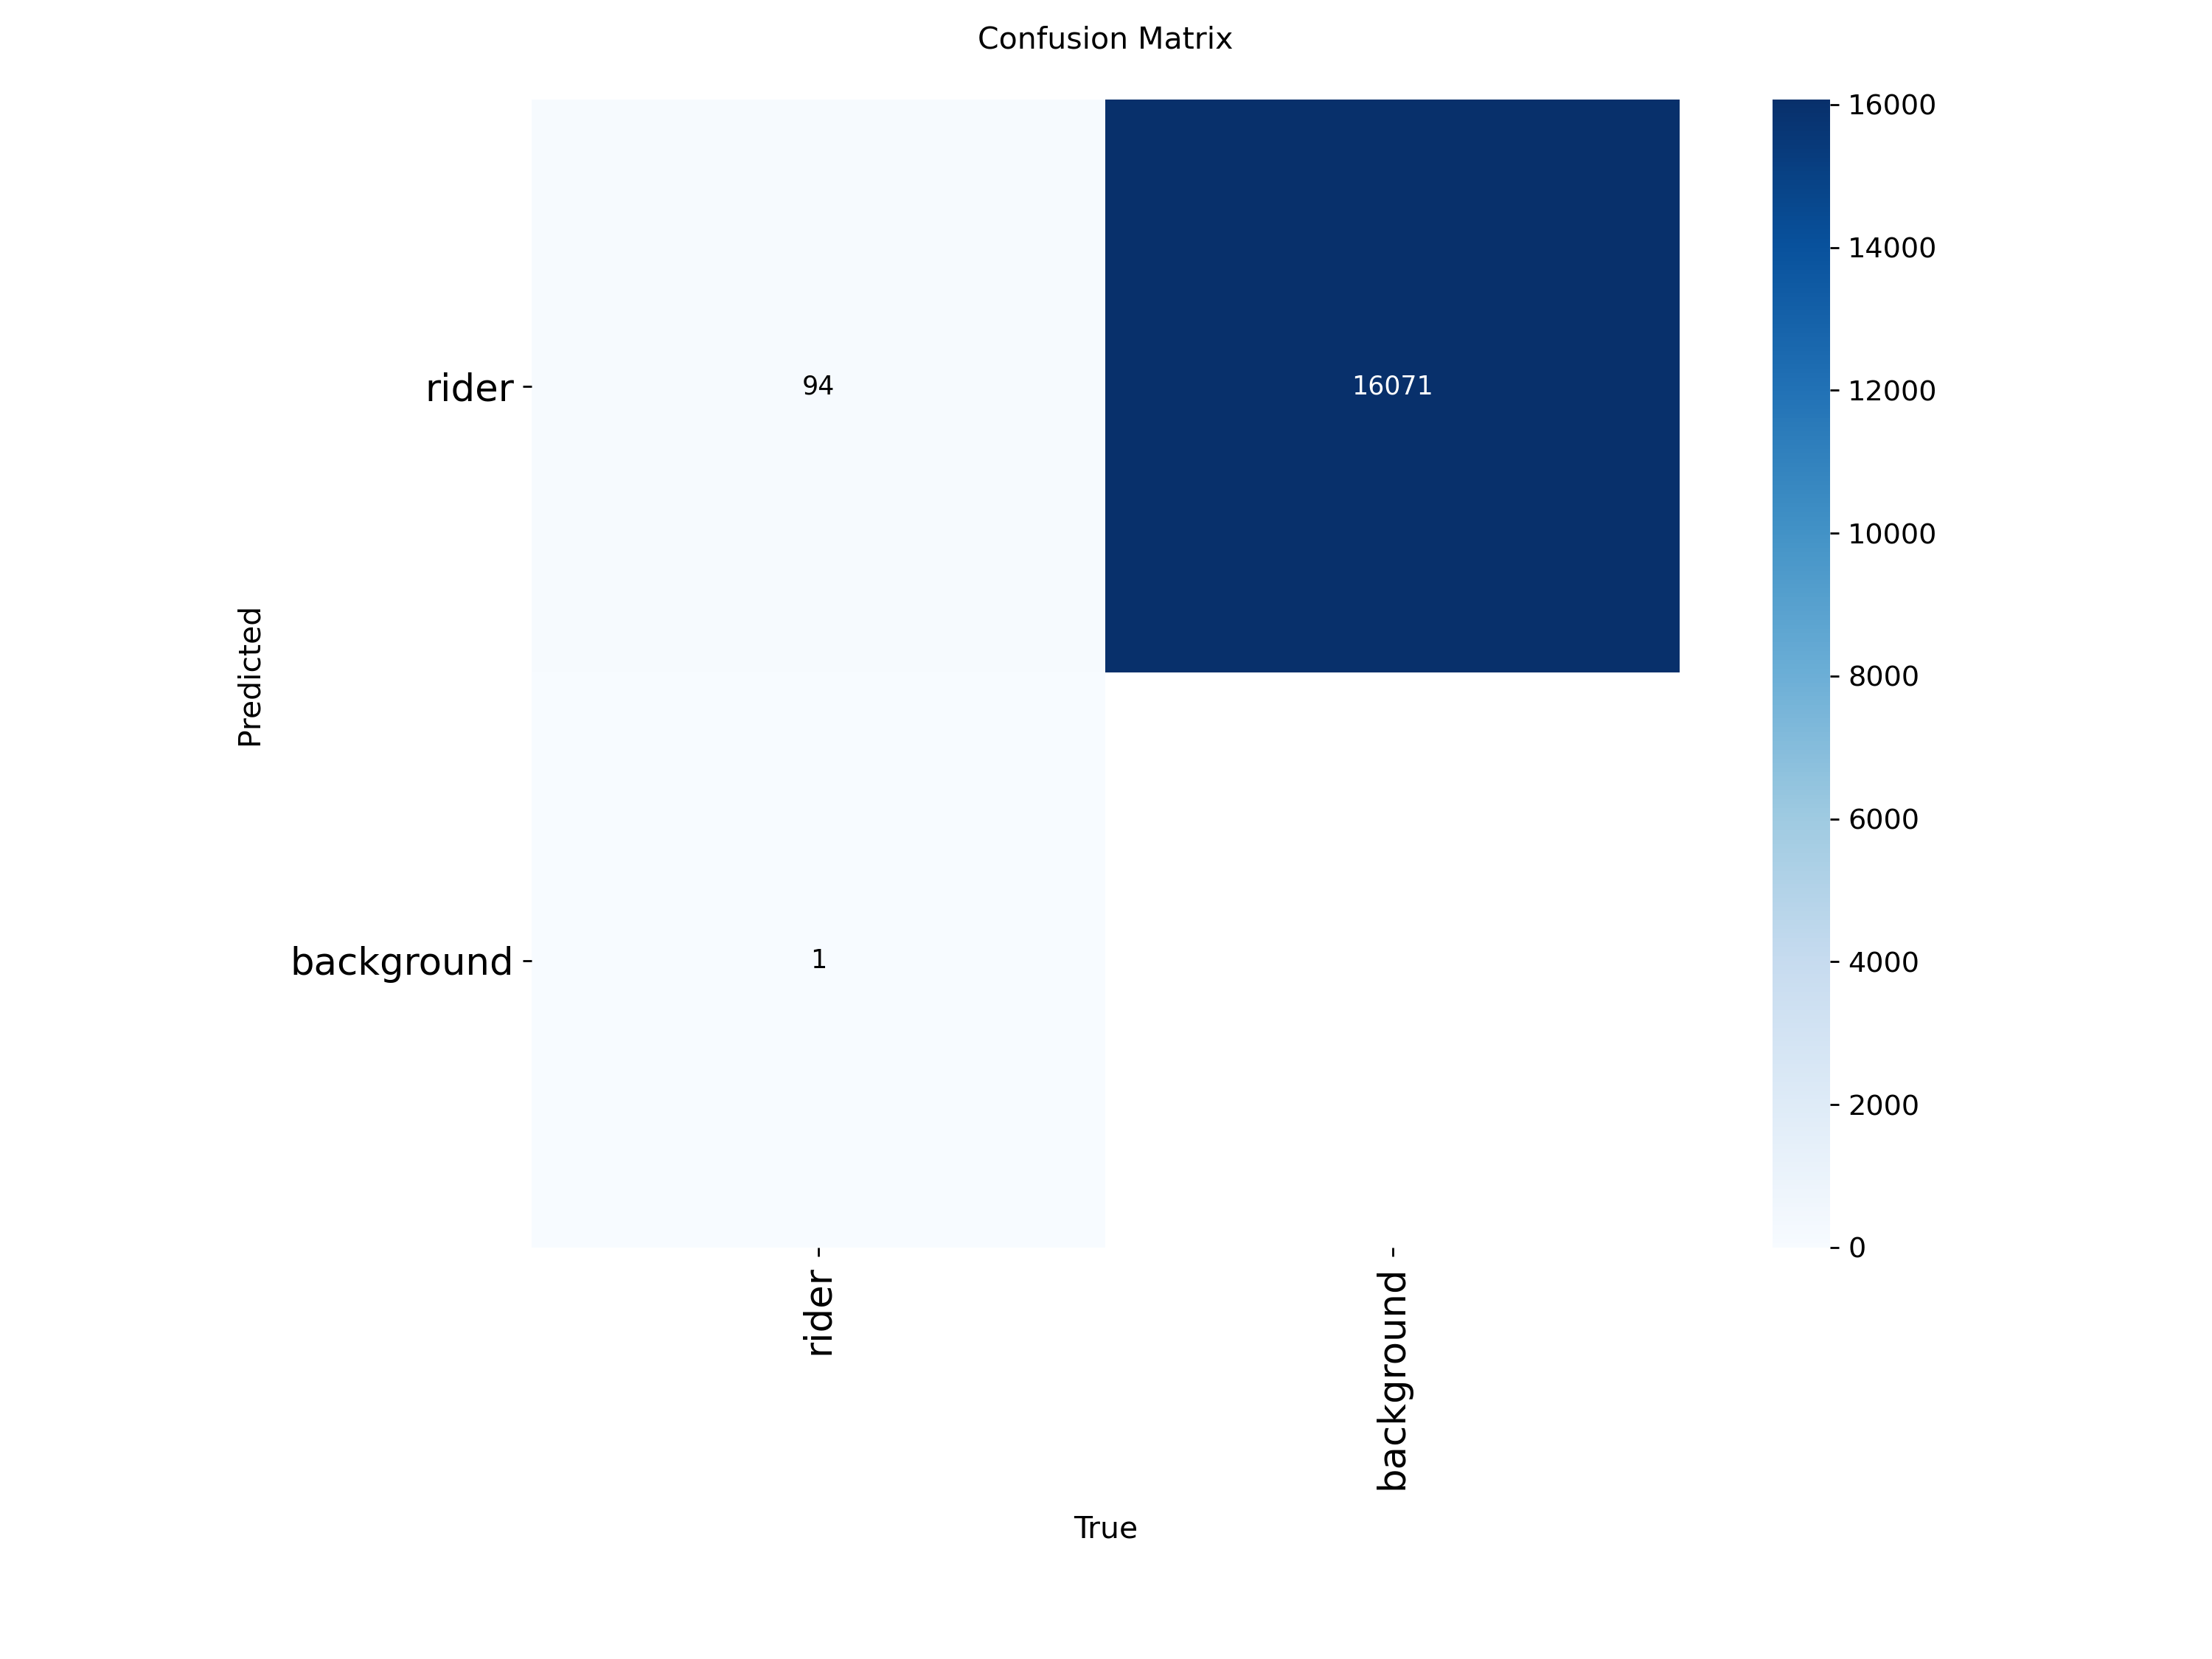


  Model   : full
  Weights : /kaggle/working/runs/full/weights/best.pt
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 476.9±200.6 MB/s, size: 637.6 KB)
val: Scanning /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/val/labels... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 437.3it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/irfanmohammad1729/two-wheeler-violation-and-license-detection/Dataset/rider_train_val/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6it/s 2.5s
                   all         58         95      0.804      0.642      0.746      0.479
Speed: 4.7ms preprocess, 9.2ms inference, 0.0ms loss, 5.1ms postprocess 

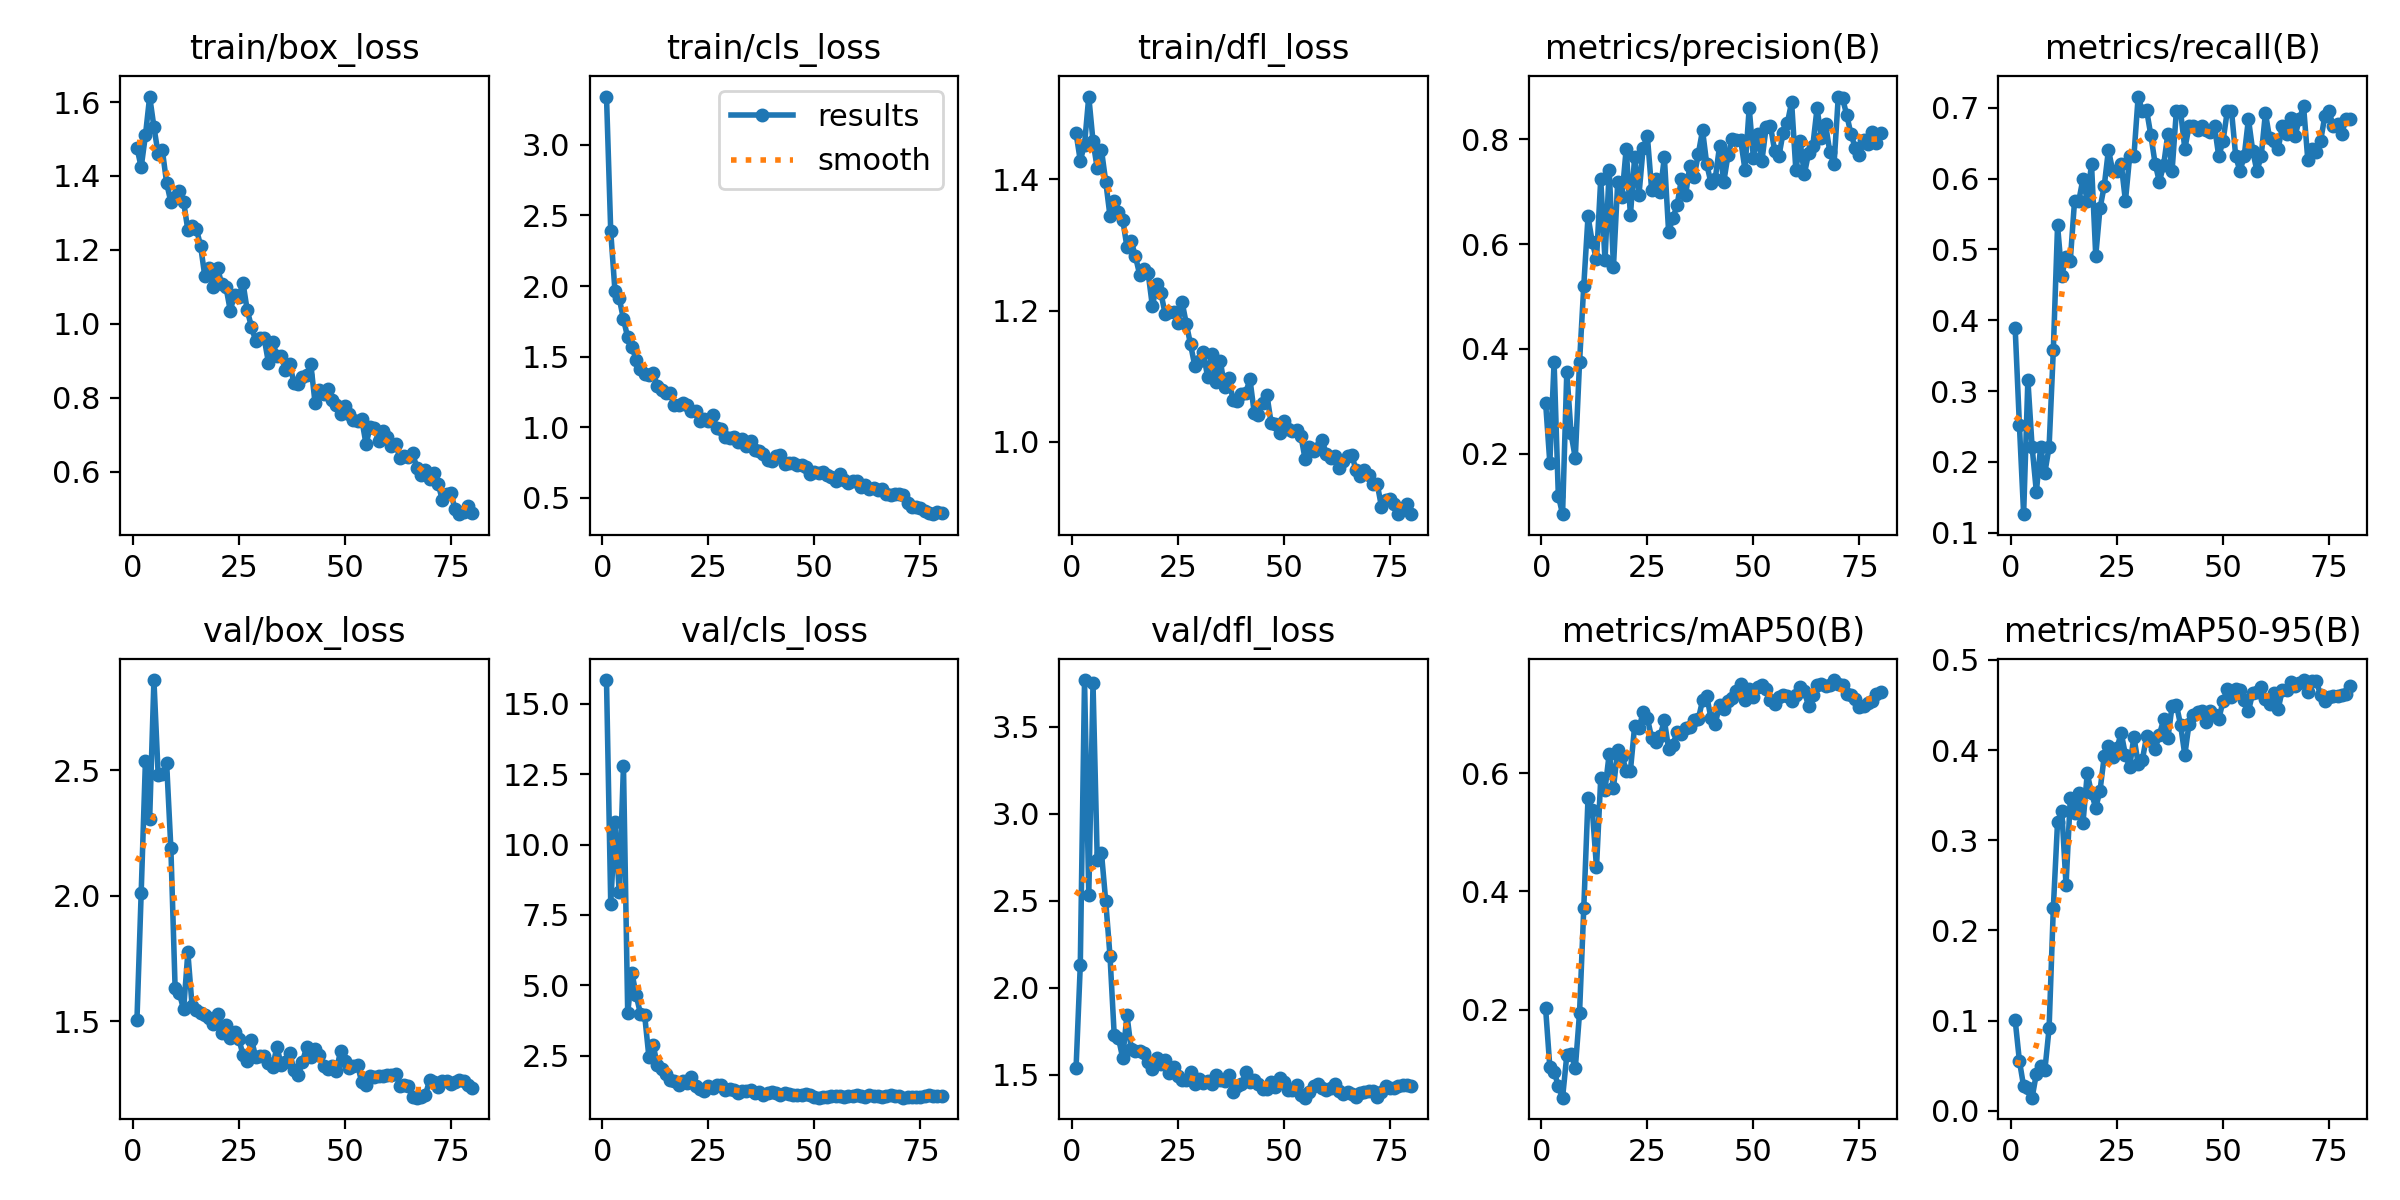


  confusion_matrix_normalized.png:


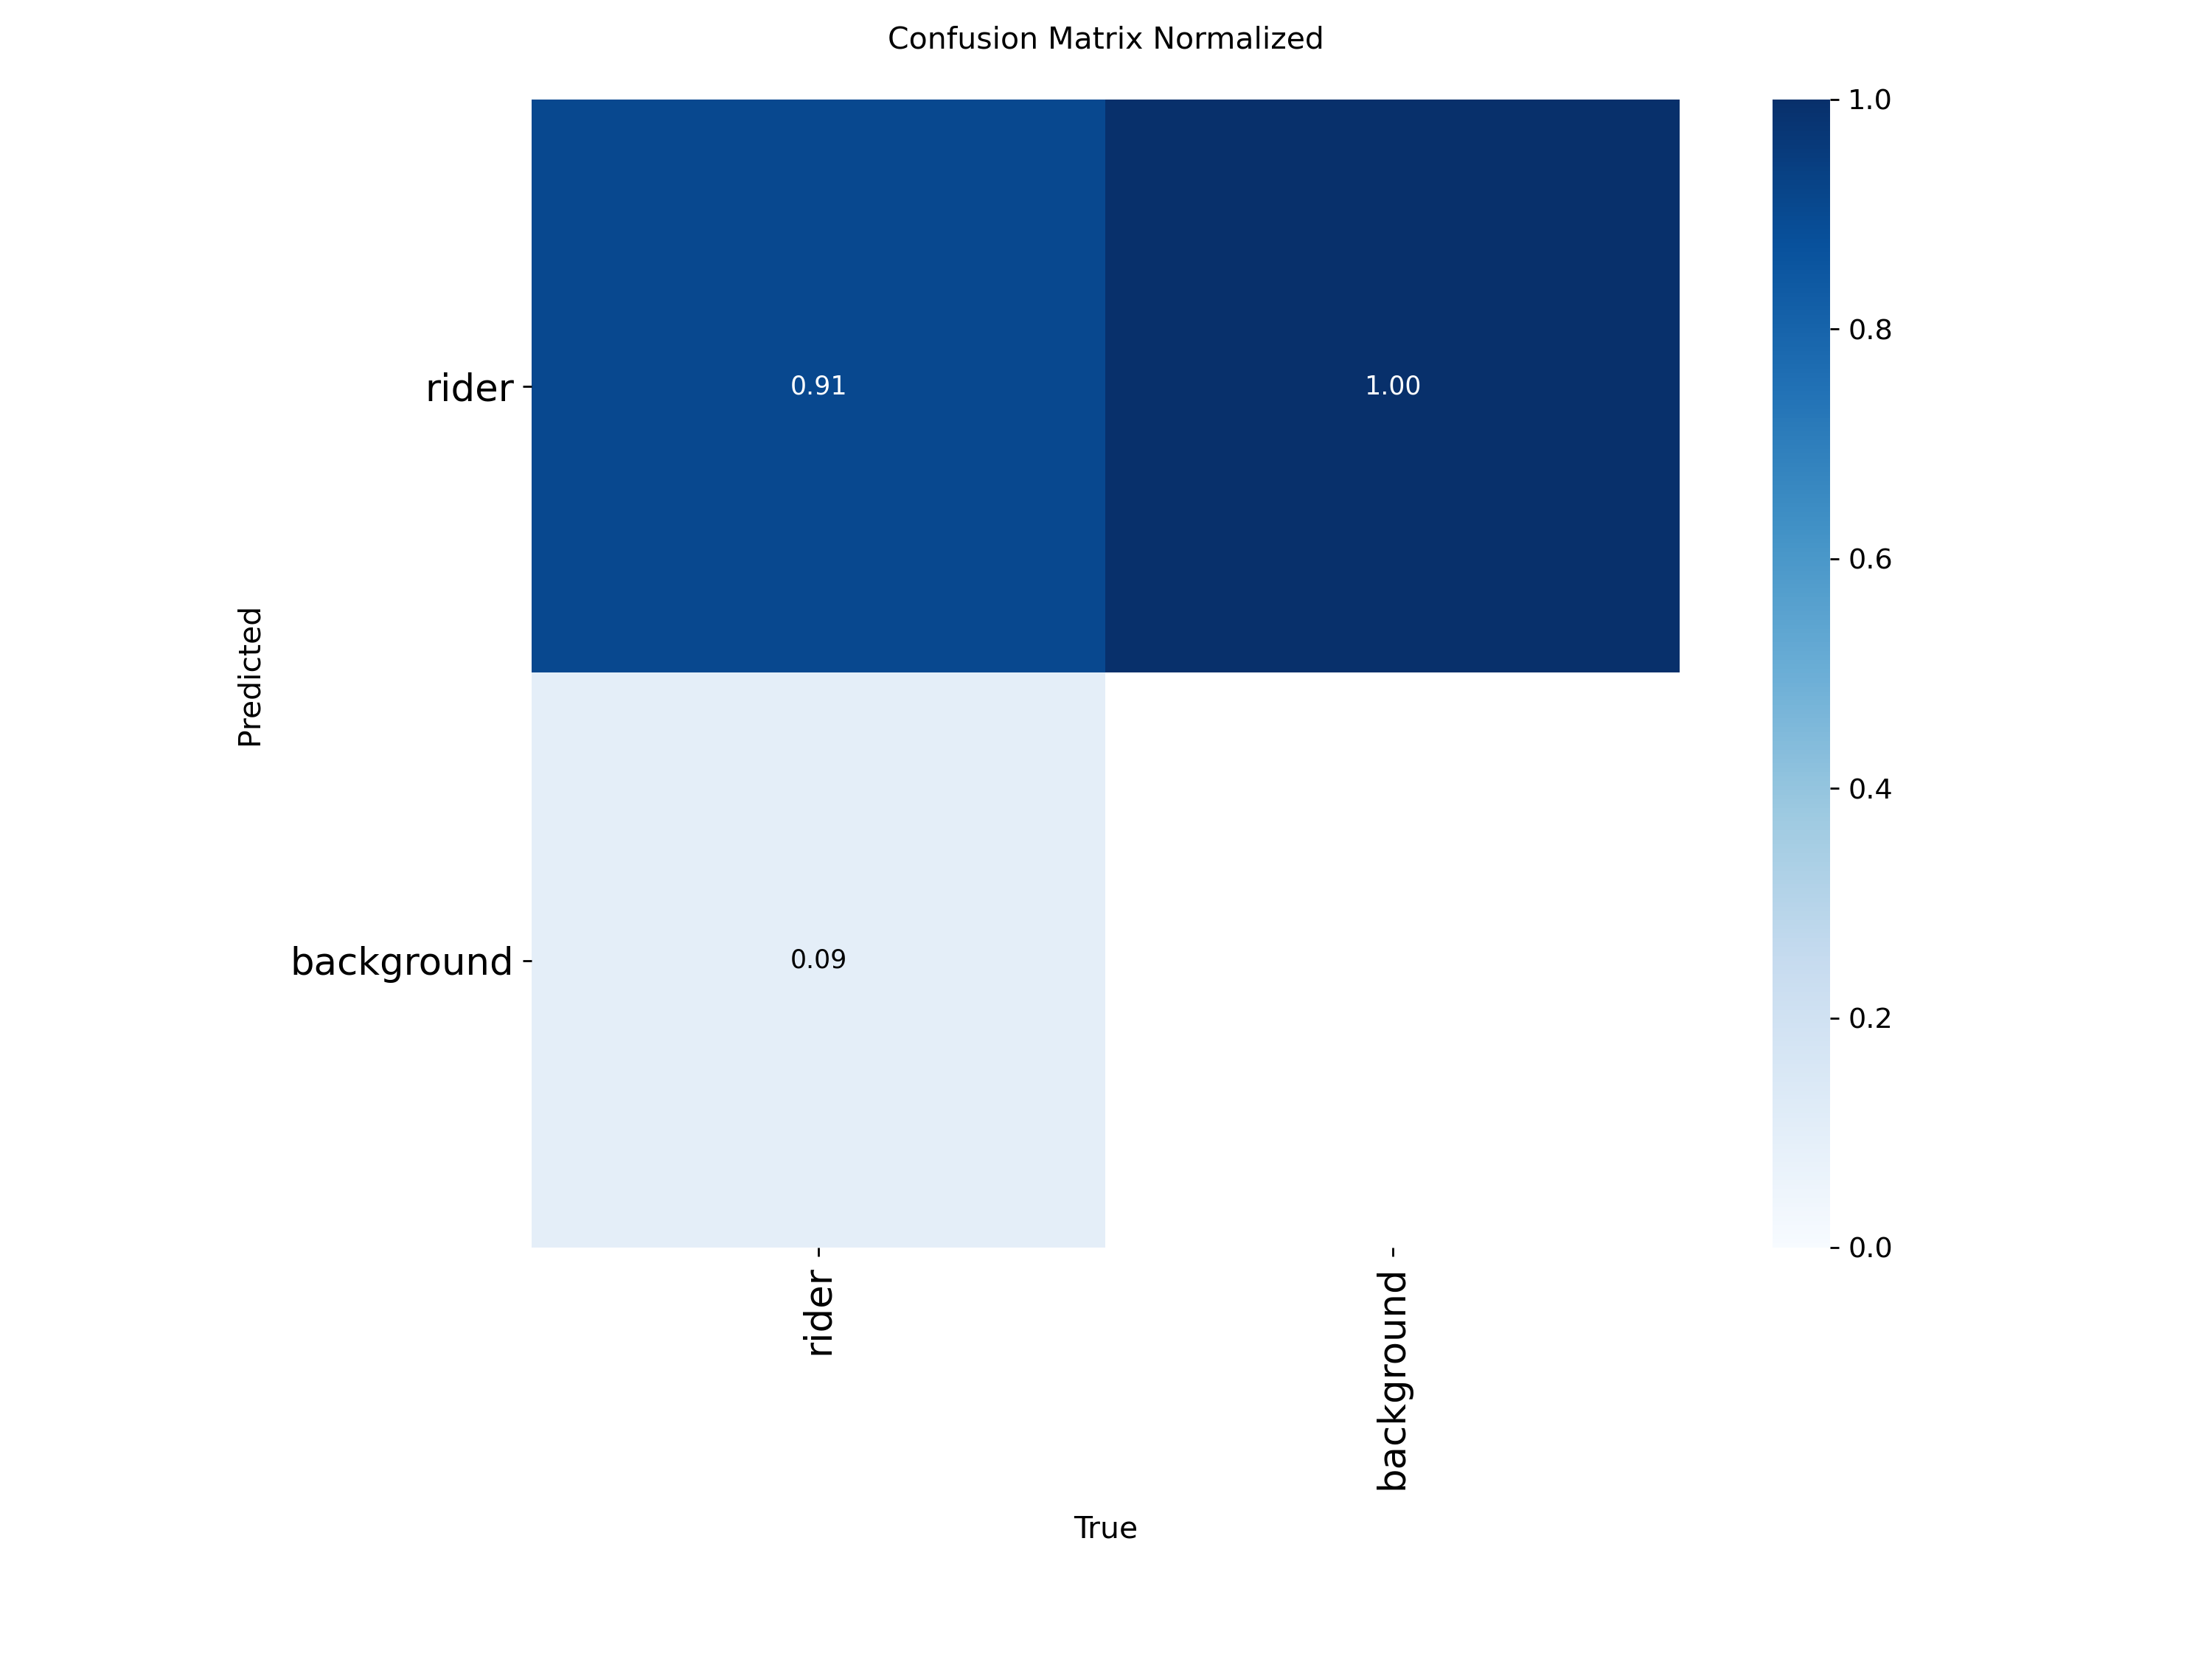


  confusion_matrix.png:


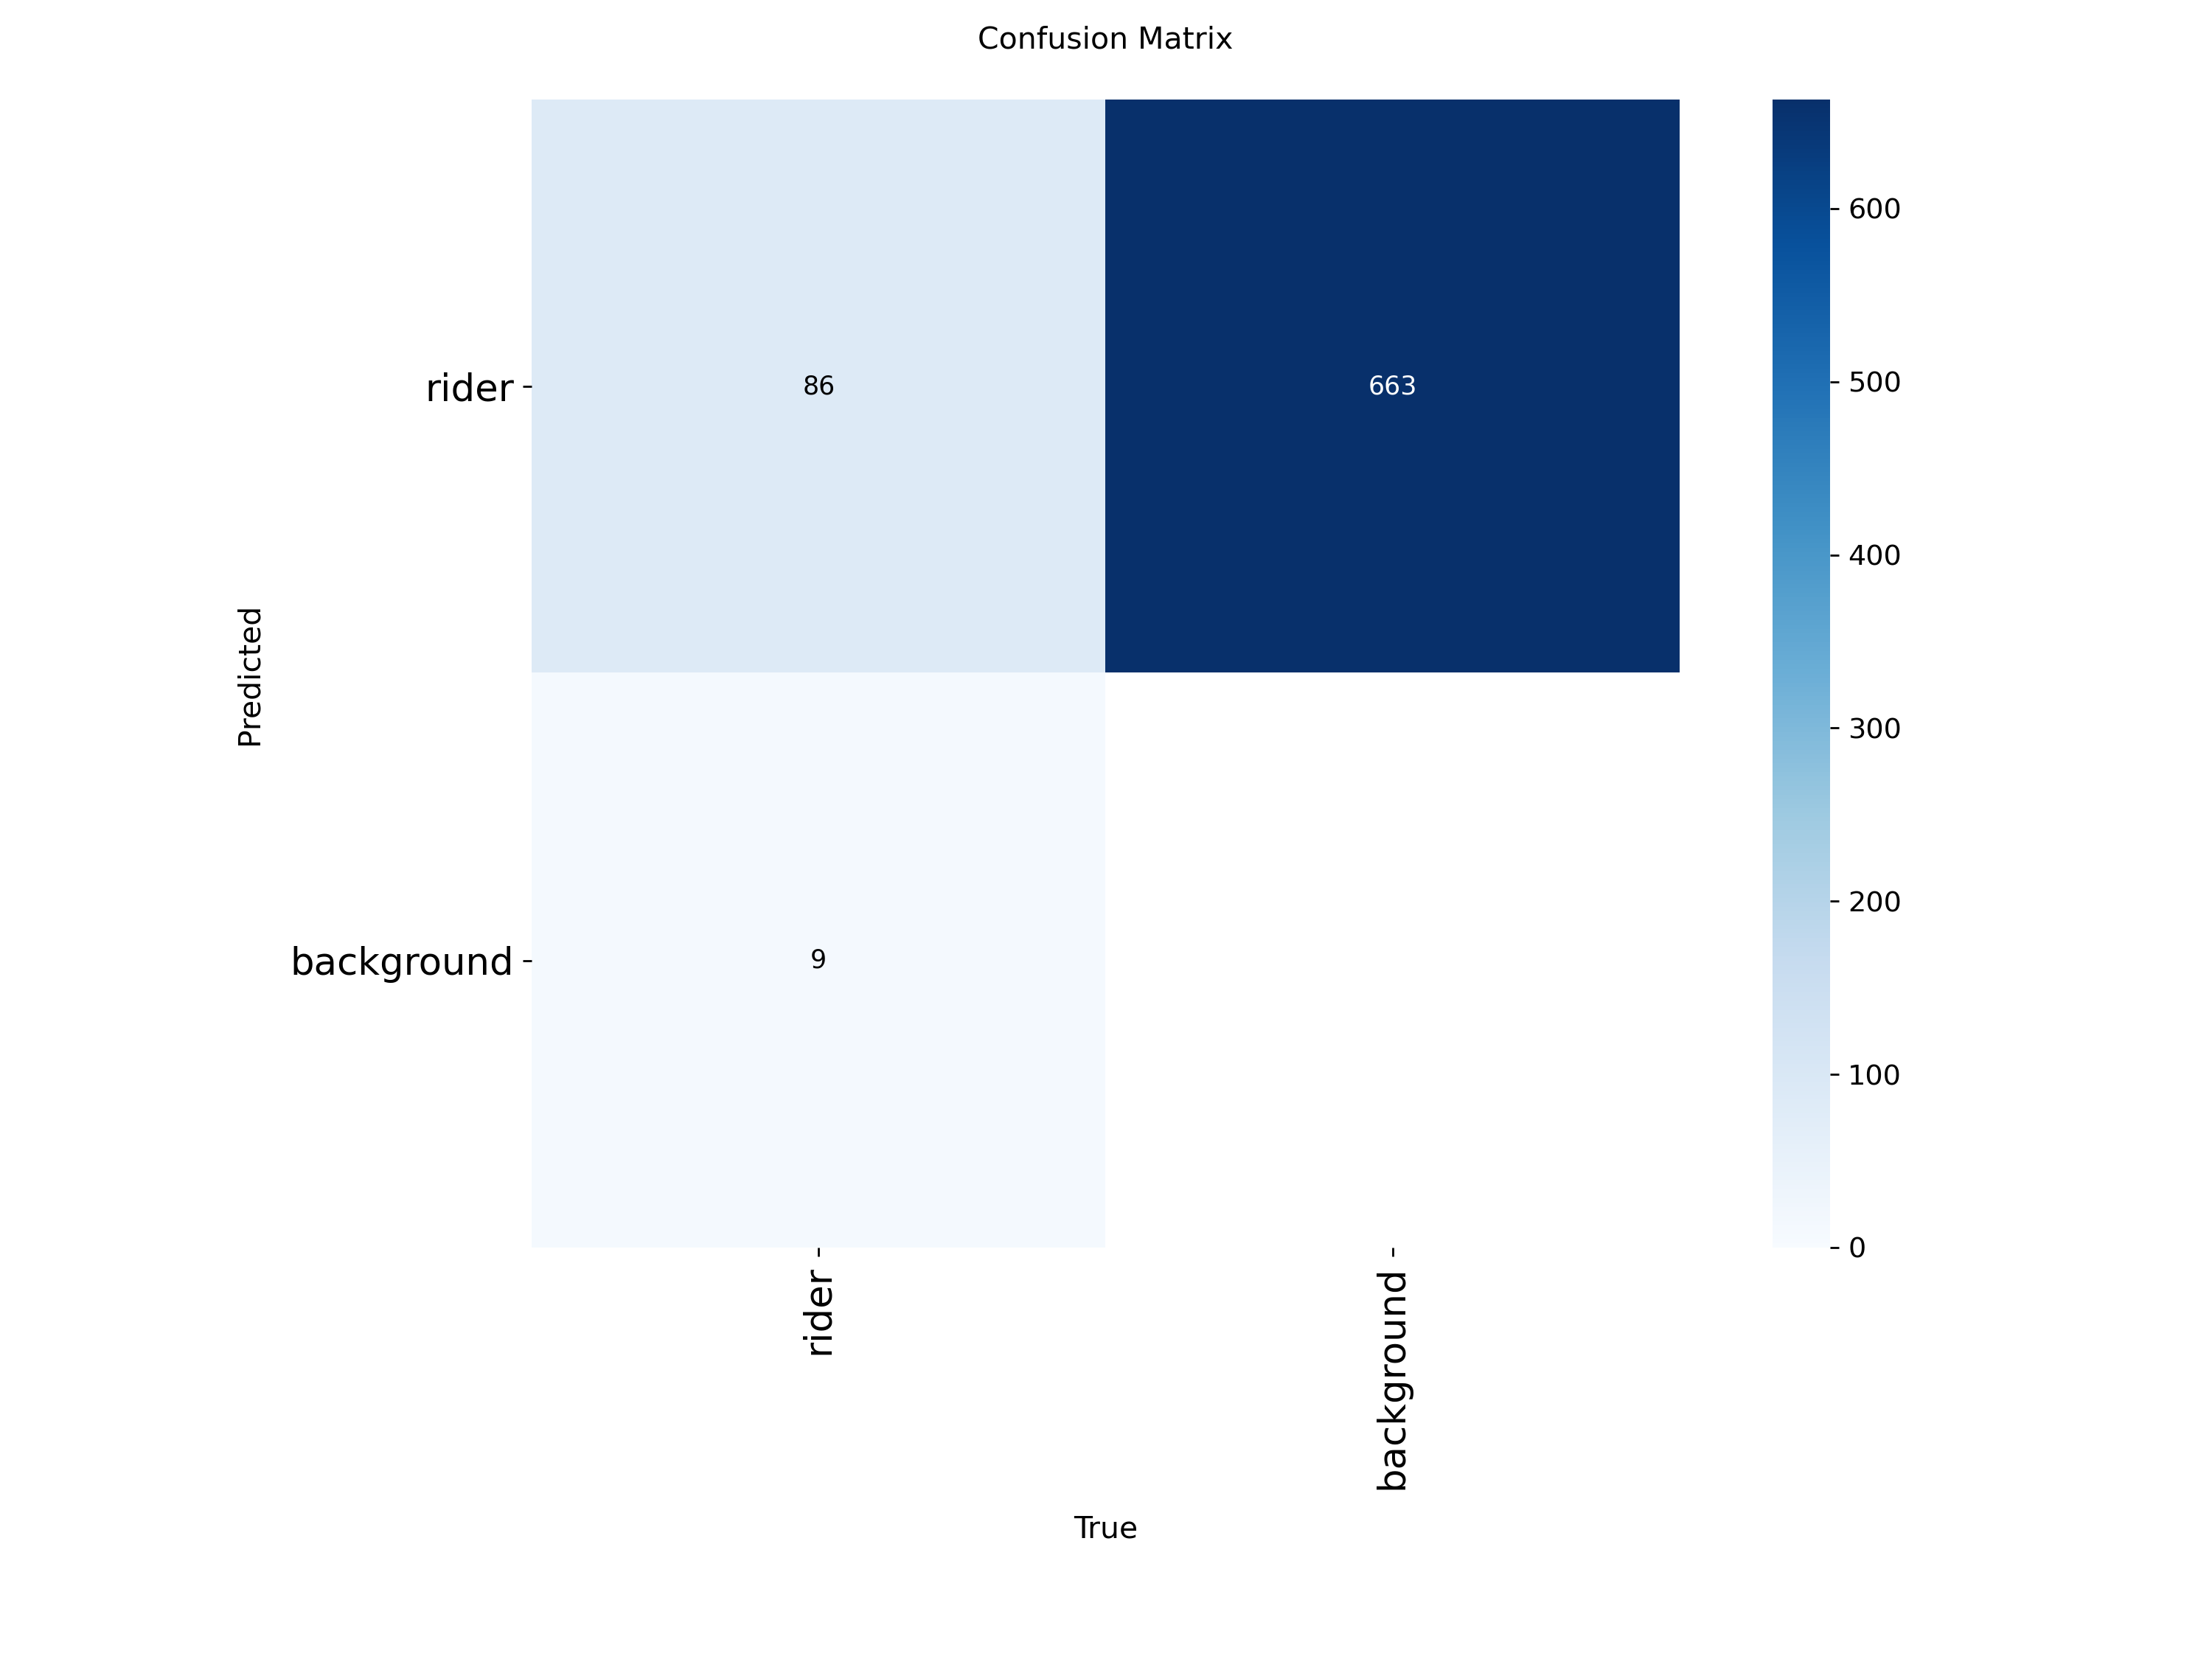

In [10]:
import glob
from pathlib import Path
from IPython.display import display as ipy_display, Image as IPyImage
from ultralytics import YOLO
import yaml

# Find all best.pt files that actually exist right now
found = glob.glob("/kaggle/working/runs/**/best.pt", recursive=True)

if not found:
    print("No trained weights found in /kaggle/working/runs/")
    print("You need to retrain first — run Cells 1, A, B, 4, C, D-1, D-2, D-3 in order.")
else:
    IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    for w in sorted(found):
        w = Path(w)
        run_name = w.parent.parent.name          # e.g. "full" or "helmet_no_helmet_train_val"
        yaml_path = f"/kaggle/working/{run_name}.yaml"

        # fallback: search for any matching yaml
        if not Path(yaml_path).exists():
            yamls = glob.glob("/kaggle/working/*.yaml")
            yaml_path = yamls[0] if yamls else None

        if yaml_path is None:
            print(f"\n[{run_name}] No yaml found — skipping val, showing plots only.")
        else:
            print(f"\n{'='*50}")
            print(f"  Model   : {run_name}")
            print(f"  Weights : {w}")
            mdl = YOLO(str(w))
            imgsz = 960 if "plate" in run_name else 640
            m = mdl.val(data=yaml_path, imgsz=imgsz, verbose=False)

            print(f"  Precision  : {m.box.mp:.4f}  ({m.box.mp*100:.1f}%)")
            print(f"  Recall     : {m.box.mr:.4f}  ({m.box.mr*100:.1f}%)")
            print(f"  mAP50      : {m.box.map50:.4f}  ({m.box.map50*100:.1f}%)")
            print(f"  mAP50-95   : {m.box.map:.4f}  ({m.box.map*100:.1f}%)")
            print(f"  Per-class:")

            # --- per-class loop (fixed: iterate over ALL classes, not just ap_class_index) ---
            for i, c in enumerate(m.box.ap_class_index):
                cname = mdl.names[c]
                ap50  = m.box.ap50[i]
                ap    = m.box.maps[i]
                print(f"    {cname:<20s}  mAP50={ap50:.4f}  mAP50-95={ap:.4f}")

        # Show plots regardless of yaml
        run_dir = w.parent.parent
        for fname in ["results.png",
                      "confusion_matrix_normalized.png",
                      "confusion_matrix.png",
                      "PR_curve.png"]:
            fp = run_dir / fname
            if fp.exists():
                print(f"\n  {fname}:")
                ipy_display(IPyImage(str(fp)))